# Win probability with Machine Learning

## Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML Scikit-Learn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

## Importing data

In [4]:
INPUT_FILE = "master_ml_dataset.csv"

df = pd.read_csv(INPUT_FILE, low_memory=False, nrows=1000000)

print(f"Succesfully loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

Succesfully loaded 1,000,000 rows and 704 columns.


In [5]:
# Target Y
y = df['target_win_t100']

# Features 
leakage_cols = ['matchId', 'timestamp', 'winningTeam', 'target_win_t100', 'type', 'team', 'actor_id']

# Filter
X = df.drop(columns=[col for col in leakage_cols if col in df.columns])

# Fill with 0-s
X = X.fillna(0)

# Only numericals
X = X.select_dtypes(include=[np.number])

print(f"Features: {X.shape[1]}")

Features: 685


In [6]:
# Unique match ids
unique_matches = df['matchId'].unique()
print(f"Összesen {len(unique_matches)} egyedi meccs van az 1 millió sorban.")

# Splitting
train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=42)

train_df = df[df['matchId'].isin(train_matches)]
test_df = df[df['matchId'].isin(test_matches)]

# Features and label
y_train = train_df['target_win_t100']
y_test = test_df['target_win_t100']

# Filter
leakage_cols = ['matchId', 'timestamp', 'winningTeam', 'target_win_t100', 'type', 'team', 'actor_id']

X_train = train_df.drop(columns=[col for col in leakage_cols if col in train_df.columns]).fillna(0).select_dtypes(include=[np.number])
X_test = test_df.drop(columns=[col for col in leakage_cols if col in test_df.columns]).fillna(0).select_dtypes(include=[np.number])

print(f"Train: {X_train.shape[0]:,} lines ({len(train_matches)} matches)")
print(f"Test: {X_test.shape[0]:,} lines ({len(test_matches)} matches)")

Összesen 921 egyedi meccs van az 1 millió sorban.
Train: 802,173 lines (736 matches)
Test: 197,827 lines (185 matches)


In [7]:
# Model
log_model = LogisticRegression(solver='saga', max_iter=500, random_state=42)

# Train
log_model.fit(X_train, y_train)

# Prediction
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1] 

e:\BME\League-of-Legends-Esport-Analitika-2026\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [8]:
print("================ RESULTS ================\n")

# Metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = auc(*roc_curve(y_test, y_prob)[:2])

print(f"ACCURACY: {accuracy * 100:.2f}%")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

================ RESULTS ================

ACCURACY: 71.39%
ROC-AUC Score: 0.7910

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70     90396
           1       0.76      0.69      0.72    107431

    accuracy                           0.71    197827
   macro avg       0.71      0.72      0.71    197827
weighted avg       0.72      0.71      0.71    197827



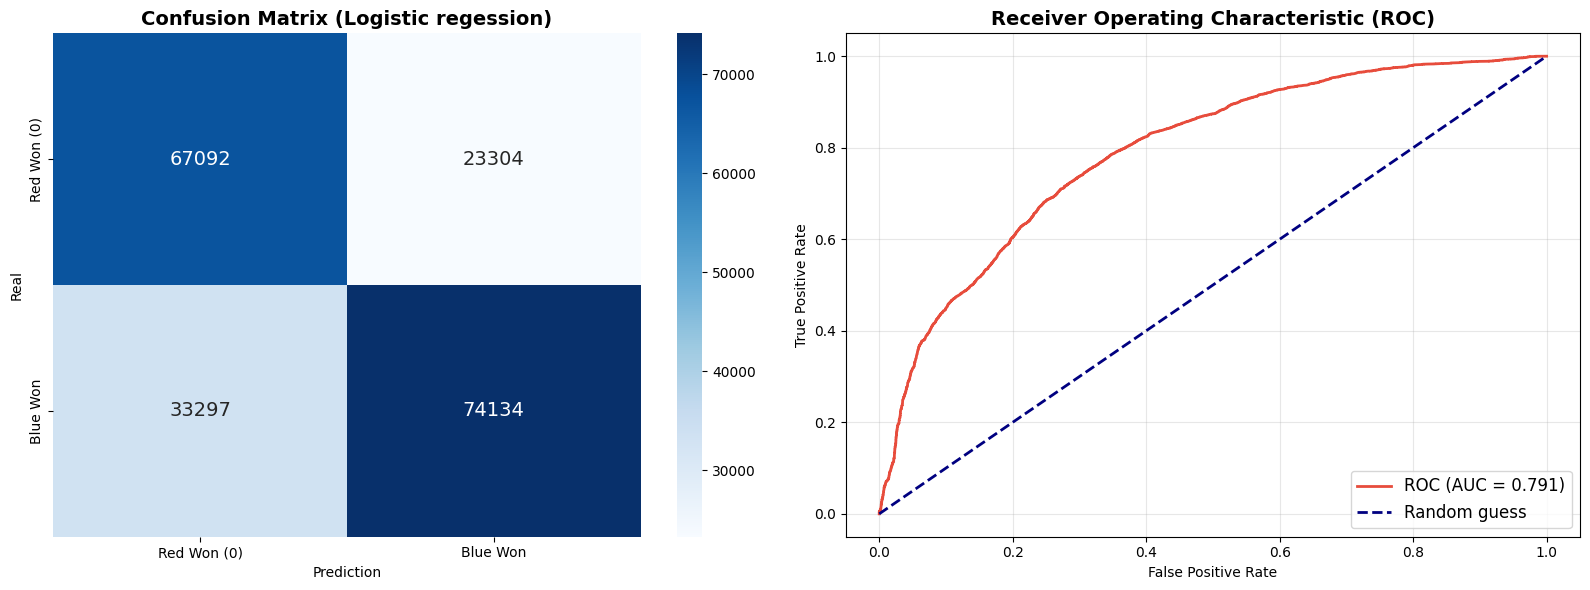


TOP 10 Most important features:
- dmg_magicDamageDoneToChampions_p4: 0.0001
- totalGold_diff                : 0.0001
- xp_p10                        : -0.0001
- stat_healthMax_t200           : -0.0001
- dmg_trueDamageTaken_p5        : 0.0001
- totalGold_t100                : 0.0001
- xp_p9                         : 0.0001
- totalGold_p9                  : -0.0001
- dmg_physicalDamageDoneToChampions_p4: -0.0001
- dmg_physicalDamageDoneToChampions_p1: 0.0001


In [19]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], annot_kws={"size": 14})
axes[0].set_title('Confusion Matrix (Logistic regession)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Real')
axes[0].set_xticklabels(['Red Won (0)', 'Blue Won'])
axes[0].set_yticklabels(['Red Won (0)', 'Blue Won'])

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
axes[1].set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc="lower right", fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': log_model.coef_[0]
})
feature_importance['Abs_Coeff'] = feature_importance['Coefficient'].abs()
top_10_features = feature_importance.sort_values(by='Abs_Coeff', ascending=False).head(10)

print("\nTOP 10 Most important features:")
for index, row in top_10_features.iterrows():
    print(f"- {row['Feature']:<30}: {row['Coefficient']:.4f}")

## XGBoost

In [15]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [16]:
params = {
    'objective': 'binary:logistic',  
    'eval_metric': 'auc',            
    'max_depth': 6,                  
    'learning_rate': 0.1,            
    'subsample': 0.8,                
    'colsample_bytree': 0.8,         
    'tree_method': 'hist',          
    'n_jobs': -1,                    # All cores
    'random_state': 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]

# Train
xgb_model = xgb.train(
    params=params, 
    dtrain=dtrain, 
    num_boost_round=300,             
    evals=evals, 
    early_stopping_rounds=20,        
    verbose_eval=20                  
)

[0]	train-auc:0.83478	test-auc:0.76231
[20]	train-auc:0.94176	test-auc:0.79869
[40]	train-auc:0.97731	test-auc:0.79955
[46]	train-auc:0.98264	test-auc:0.80053


In [17]:
# Results

# Predictions
y_prob_xgb = xgb_model.predict(dtest)
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

# Metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = auc(*roc_curve(y_test, y_prob_xgb)[:2])

print("================ XGBOOST RESULTS ================")
print(f"ACCURACY:      {accuracy_xgb * 100:.2f}%")
print(f"ROC-AUC SCORE: {roc_auc_xgb:.4f}\n")

print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))

================ XGBOOST RESULTS ================
ACCURACY:      72.45%
ROC-AUC SCORE: 0.8005

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.70      0.70     90396
           1       0.74      0.75      0.75    107431

    accuracy                           0.72    197827
   macro avg       0.72      0.72      0.72    197827
weighted avg       0.72      0.72      0.72    197827



C:\Users\hp\AppData\Local\Temp\ipykernel_30416\3381807484.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_15_xgb, palette='magma')


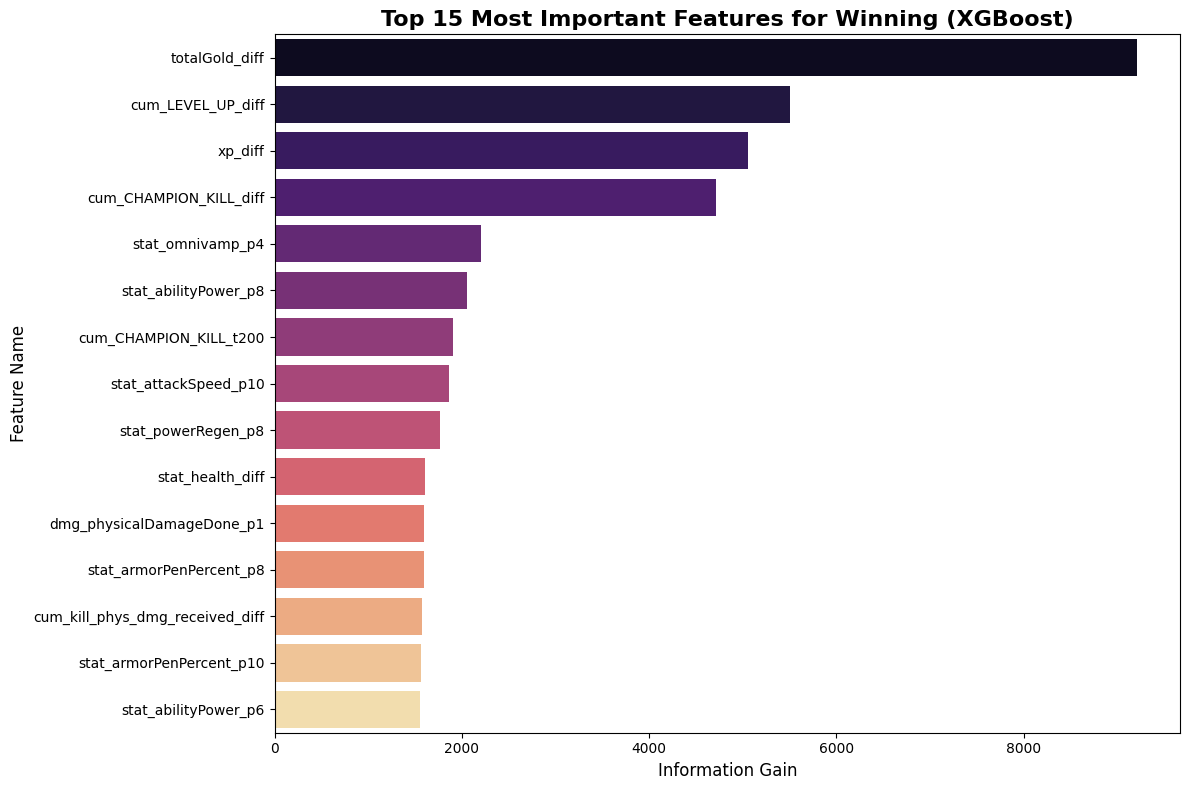

In [18]:
# Visualization

importance_dict = xgb_model.get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': list(importance_dict.keys()),
    'Importance': list(importance_dict.values())
})

top_15_xgb = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=top_15_xgb, palette='magma')

plt.title('Top 15 Most Important Features for Winning (XGBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Information Gain', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

## Ötletek

Szekvenciális modell (LSTM, Transformers)

Mikor dől el végleg a meccs

Több feature